In [2]:
import shutup; shutup.please()
import pandas as pd
import numpy as np
import re
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
DA_FILES = [
    r"Entso_e\DA_price\GUI_ENERGY_PRICES_202212312300-202312312300.csv",
    r"Entso_e\DA_price\GUI_ENERGY_PRICES_202312312300-202412312300.csv",
    r"Entso_e\DA_price\GUI_ENERGY_PRICES_202412312300-202512312300.csv",
    r"Entso_e\DA_price\GUI_ENERGY_PRICES_202512312300-202612312300.csv",
]

LOAD_FILES = [
    r"Entso_e\Load\GUI_TOTAL_LOAD_DAYAHEAD_202212312300-202312312300.csv",
    r"Entso_e\Load\GUI_TOTAL_LOAD_DAYAHEAD_202312312300-202412312300.csv",
    r"Entso_e\Load\GUI_TOTAL_LOAD_DAYAHEAD_202412312300-202512312300.csv",
    r"Entso_e\Load\GUI_TOTAL_LOAD_DAYAHEAD_202512312300-202612312300.csv",
]

#// Optional Data - Generation Forecast
TOTALGENERATION_FILES = [
    r"Entso_e\GenerationFC\GUI_TOTAL_GENERATION_FORECAST_202212312300-202312312300.csv",
    r"Entso_e\GenerationFC\GUI_TOTAL_GENERATION_FORECAST_202312312300-202412312300.csv",
    r"Entso_e\GenerationFC\GUI_TOTAL_GENERATION_FORECAST_202412312300-202512312300.csv",
    r"Entso_e\GenerationFC\GUI_TOTAL_GENERATION_FORECAST_202512312300-202612312300.csv"
]

RENEWABLES_FILES_SOLAR = [
    r"Entso_e\RenewableForecast_solar\GUI_WIND_SOLAR_GENERATION_FORECAST_SOLAR_202212312300-202312312300.csv",
    r"Entso_e\RenewableForecast_solar\GUI_WIND_SOLAR_GENERATION_FORECAST_SOLAR_202312312300-202412312300.csv",
    r"Entso_e\RenewableForecast_solar\GUI_WIND_SOLAR_GENERATION_FORECAST_SOLAR_202412312300-202512312300.csv",
    r"Entso_e\RenewableForecast_solar\GUI_WIND_SOLAR_GENERATION_FORECAST_SOLAR_202512312300-202612312300.csv"
]

RENEWABLES_FILES_WIND = [
    r"Entso_e\RenewablesForecast_wind\GUI_WIND_SOLAR_GENERATION_FORECAST_ONSHORE_202212312300-202312312300.csv",
    r"Entso_e\RenewablesForecast_wind\GUI_WIND_SOLAR_GENERATION_FORECAST_ONSHORE_202312312300-202412312300.csv",
    r"Entso_e\RenewablesForecast_wind\GUI_WIND_SOLAR_GENERATION_FORECAST_ONSHORE_202412312300-202512312300.csv",
    r"Entso_e\RenewablesForecast_wind\GUI_WIND_SOLAR_GENERATION_FORECAST_ONSHORE_202512312300-202612312300.csv"
]

In [4]:
# ----------------------------
# User settings (adjust here)
# ----------------------------
MTU_COL = "MTU (CET/CEST)"
TZ = "Europe/Budapest"
PRICE_COL_CANDIDATES = [
    "Day-ahead Price (EUR/MWh)",
    "Day-ahead Price (EUR/MWh )",
    "Day-ahead Price(EUR/MWh)",
]

BREAKPOINT = pd.Timestamp("2025-10-01", tz=TZ)

# Choose evaluation window length
TEST_DAYS = 30          # last 30 days of the REAL_15M segment
MIN_TRAIN_DAYS = 90    # require at least ~3 months training inside REAL_15M
FEATURES = [
    "y_hour", "hour_ramp_1", "hour_ramp_24",
    "hod", "dow", "month", "is_weekend",
    "q_in_hour",
]



SYNTH_WEIGHT = 0.3          # Model2: weight for synthetic samples (REAL weight = 1.0)
RETRAIN_EVERY = 1           # retrain models every N forecast days (1 = daily retrain)
TEST_DAYS = 30              # number of REAL days at the end to evaluate with rolling-origin
VAL_DAYS = 14               # optional validation window inside training for sanity-check metrics (not used for early stop here)
# Feature lags in 15-min steps
STATE_LAGS = [1, 4, 8, 24, 96, 192, 672]   # 15m, 1h, 2h, 6h, 1d, 2d, 1w
STATE_ROLL_WINS = [24, 96, 672]            # rolling windows on past y (6h, 1d, 1w)
# Feature columns
STATE_FEATURES = (
    ["last_y"]
    + [f"lag_{L}_t0" for L in STATE_LAGS]
    + ["ramp_1h_t0", "ramp_6h_t0", "ramp_1d_t0"]
    + [f"roll_mean_{w}_t0" for w in STATE_ROLL_WINS]
    + [f"roll_std_{w}_t0" for w in STATE_ROLL_WINS]
)

HORIZON_FEATURES = [
    "h", "q_in_hour_target", "qod_target", "hod_target", "dow_target", "month_target", "is_weekend_target",
    "load_fc_target", "load_ramp_1h_target", "load_ramp_6h_target", "generation_fc", "renewables_solar_fc","renewables_wind_fc",
    "load_day_mean", "load_day_max", "load_day_min", "q_in_hour_sin", "q_in_hour_cos", "qod_sin", "qod_cos", "hod_sin", "hod_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"
]

FEATURE_COLS = STATE_FEATURES + HORIZON_FEATURES

In [5]:
def parse_dt_with_label(s: str) -> pd.Timestamp:
    """
    Input example: '31/03/2024 01:00:00 (CET)' or '(CEST)'
    Returns tz-aware timestamp in Europe/Budapest.
    """
    s = s.strip()
    m = re.match(r"^(.*?)(?:\s+\((CET|CEST)\))?$", s)
    if not m:
        raise ValueError(f"Unrecognized datetime format: {s}")
    dt_part = m.group(1).strip()
    label = m.group(2)  # 'CET' or 'CEST' or None

    dt = pd.to_datetime(dt_part, format="%d/%m/%Y %H:%M:%S", errors="raise")

    # If label missing, fall back to localize without infer (choose a safe policy)
    if label is None:
        # safest conservative fallback: treat as Europe/Budapest and shift forward if nonexistent
        return dt.tz_localize(TZ, ambiguous="NaT", nonexistent="shift_forward")

    offset_hours = 1 if label == "CET" else 2  # CET=UTC+1, CEST=UTC+2
    # Convert local time with known offset -> UTC -> Europe/Budapest
    utc = (dt - pd.Timedelta(hours=offset_hours)).tz_localize("UTC")
    return utc.tz_convert(TZ)

def parse_mtu_start_end(mtu: str):
    a, b = [x.strip() for x in mtu.split("-")]
    start = parse_dt_with_label(a)
    end   = parse_dt_with_label(b)
    return start, end

In [6]:
def pick_price_col(df: pd.DataFrame) -> str:
    for c in PRICE_COL_CANDIDATES:
        if c in df.columns:
            return c
    raise ValueError(f"Could not find day-ahead price column. Available columns: {list(df.columns)}")

In [7]:
def load_one(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if MTU_COL not in df.columns:
        raise ValueError(f"Missing '{MTU_COL}' in {path}. Columns: {list(df.columns)}")

    # If the file contains multiple areas, keep HU if possible
    if "Area" in df.columns:
        hu_mask = df["Area"].astype(str).str.contains(r"\bHU\b|Hungary", case=False, na=False)
        if hu_mask.any():
            df = df.loc[hu_mask].copy()

    price_col = pick_price_col(df)

    # Parse interval boundaries
    starts, ends = zip(*df["MTU (CET/CEST)"].astype(str).map(parse_mtu_start_end))
    df["start"] = pd.DatetimeIndex(starts)
    df["end"]   = pd.DatetimeIndex(ends)


    df["y"] = pd.to_numeric(df[price_col], errors="coerce")
    df = df.dropna(subset=["y"])

    out = df[["start", "end", "y"]].copy()
    out["source_file"] = path
    out["delta_min"] = (out["end"] - out["start"]).dt.total_seconds() / 60.0
    return out

In [8]:
# --- Load Da files ---
parts = []
for f in DA_FILES:
    print(f)
    try:
        parts.append(load_one(f))
    except FileNotFoundError:
        # ignore optional missing file(s)
        pass

raw = pd.concat(parts, ignore_index=True)
raw = raw.drop_duplicates(subset=["start"]).sort_values("start").reset_index(drop=True)
print(raw)
print("Loaded rows:", len(raw))
print("Date range:", raw["start"].min(), "→", raw["start"].max())
print("\nResolution (minutes) counts:")
print(raw["delta_min"].value_counts(dropna=False).head(10))

Entso_e\DA_price\GUI_ENERGY_PRICES_202212312300-202312312300.csv
Entso_e\DA_price\GUI_ENERGY_PRICES_202312312300-202412312300.csv
Entso_e\DA_price\GUI_ENERGY_PRICES_202412312300-202512312300.csv
Entso_e\DA_price\GUI_ENERGY_PRICES_202512312300-202612312300.csv
                          start                       end       y  \
0     2023-01-01 00:00:00+01:00 2023-01-01 01:00:00+01:00   19.76   
1     2023-01-01 01:00:00+01:00 2023-01-01 02:00:00+01:00    0.19   
2     2023-01-01 02:00:00+01:00 2023-01-01 03:00:00+01:00    0.07   
3     2023-01-01 03:00:00+01:00 2023-01-01 04:00:00+01:00    0.01   
4     2023-01-01 04:00:00+01:00 2023-01-01 05:00:00+01:00   -0.77   
...                         ...                       ...     ...   
59491 2026-03-13 22:45:00+01:00 2026-03-13 23:00:00+01:00  116.90   
59492 2026-03-13 23:00:00+01:00 2026-03-13 23:15:00+01:00  133.69   
59493 2026-03-13 23:15:00+01:00 2026-03-13 23:30:00+01:00  115.61   
59494 2026-03-13 23:30:00+01:00 2026-03-13 23:45:0

In [9]:
# --- Build a continuous 15-minute grid and mark observed points ---
raw["resolution"] = np.where(np.isclose(raw["delta_min"], 15), "15min",
                      np.where(np.isclose(raw["delta_min"], 60), "60min", "other"))
ts = raw.set_index("start")[["y", "resolution", "source_file"]].sort_index()

full_index = pd.date_range(ts.index.min(), ts.index.max(), freq="15min", tz=TZ)
grid = ts.reindex(full_index)

grid.index.name = "ts"
grid["is_observed"] = grid["y"].notna()
# Calendar features (useful later; harmless now)
grid["qod"] = (grid.index.hour * 4 + (grid.index.minute // 15)).astype(int)  # 0..95 (mostly)
grid["dow"] = grid.index.dayofweek.astype(int)  # 0=Mon
grid["month"] = grid.index.month.astype(int)
grid["is_weekend"] = (grid["dow"] >= 5).astype(int)

# --- Diagnostics ---
# Missingness overall
missing_ratio = 1.0 - grid["is_observed"].mean()
print("\nMissing ratio on full 15-min grid:", round(missing_ratio, 4))
grid


Missing ratio on full 15-min grid: 0.4694


,y,resolution,source_file,is_observed,qod,dow,month,is_weekend
ts,,,,,,,,
2023-01-01 00:00:00+01:00,19.76,60min,Entso_e\DA_price\GUI_ENERGY_PRICES_20221231230...,True,0,6,1,1
2023-01-01 00:15:00+01:00,NaN,NaN,NaN,False,1,6,1,1
2023-01-01 00:30:00+01:00,NaN,NaN,NaN,False,2,6,1,1
2023-01-01 00:45:00+01:00,NaN,NaN,NaN,False,3,6,1,1
2023-01-01 01:00:00+01:00,0.19,60min,Entso_e\DA_price\GUI_ENERGY_PRICES_20221231230...,True,4,6,1,1
...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,116.90,15min,Entso_e\DA_price\GUI_ENERGY_PRICES_20251231230...,True,91,4,3,0
2026-03-13 23:00:00+01:00,133.69,15min,Entso_e\DA_price\GUI_ENERGY_PRICES_20251231230...,True,92,4,3,0
2026-03-13 23:15:00+01:00,115.61,15min,Entso_e\DA_price\GUI_ENERGY_PRICES_20251231230...,True,93,4,3,0


In [10]:
# Check for DST-day anomalies: count quarters per day
daily_counts = grid["is_observed"].groupby(grid.index.normalize()).sum()
print("\nObserved 15-min points per day (sample extremes):")
print("min:", int(daily_counts.min()), "max:", int(daily_counts.max()))
print(daily_counts.value_counts().sort_index().tail(10))


Observed 15-min points per day (sample extremes):
min: 23 max: 100
is_observed
23       2
24     727
25       2
92       1
96     435
100      1
Name: count, dtype: int64


In [11]:
# Identify days that are not 96 (could be DST days or gaps)
odd_days = daily_counts[(daily_counts != 96) & (daily_counts != 0)]
print("\nDays with observed count not equal to 96 (show up to 15):")
print(odd_days.tail(15))


Days with observed count not equal to 96 (show up to 15):
ts
2024-12-19 00:00:00+01:00     24
2024-12-20 00:00:00+01:00     24
2024-12-21 00:00:00+01:00     24
2024-12-22 00:00:00+01:00     24
2024-12-23 00:00:00+01:00     24
2024-12-24 00:00:00+01:00     24
2024-12-25 00:00:00+01:00     24
2024-12-26 00:00:00+01:00     24
2024-12-27 00:00:00+01:00     24
2024-12-28 00:00:00+01:00     24
2024-12-29 00:00:00+01:00     24
2024-12-30 00:00:00+01:00     24
2024-12-31 00:00:00+01:00     24
2025-03-30 00:00:00+01:00     92
2025-10-26 00:00:00+02:00    100
Name: is_observed, dtype: int64


In [12]:
# Quick look around 2025-10-01 (structural breakpoint you mentioned)
breakpoint = pd.Timestamp("2025-10-01", tz=TZ)
window = grid.loc[breakpoint - pd.Timedelta(days=3): breakpoint + pd.Timedelta(days=3)]
print("\nResolution labels around 2025-10-01 (observed rows only):")
print(window.loc[window["is_observed"], "resolution"].value_counts(dropna=False))


Resolution labels around 2025-10-01 (observed rows only):
resolution
15min    577
Name: count, dtype: int64


In [13]:
# Save Phase 1 outputs for Phase 2
# - raw: original observations (mixed resolution)
# - grid: full 15-min grid with observed flags (hourly points appear sparsely)
PHASE1_RAW = raw
PHASE1_GRID = grid

print("\nPhase 1 complete. Objects in memory: PHASE1_RAW, PHASE1_GRID")


Phase 1 complete. Objects in memory: PHASE1_RAW, PHASE1_GRID


In [14]:
# -------------------------------
# 0) Extract TRUE 15-min segment (post-breakpoint) from Phase 1 grid
# -------------------------------
g = PHASE1_GRID.copy()

# Keep only observed points
g = g[g["is_observed"]].copy()

# Identify true 15-min portion (resolution label might be missing depending on your Phase 1;
# if you have it, use it; otherwise infer from spacing by resampling completeness)
if "resolution" in g.columns:
    g15 = g[(g.index >= BREAKPOINT) & (g["resolution"] == "15min")].copy()
else:
    # Fallback: assume post-breakpoint is 15-min if present; still require dense days
    g15 = g[g.index >= BREAKPOINT].copy()

# Basic sanity: require enough data
if g15.empty:
    raise ValueError("No observed 15-min data found after breakpoint. Check Phase 1 output and breakpoint.")

# Ensure sorted and regular-ish
g15 = g15.sort_index()
g15 = g15[["y"]].copy()

In [15]:
# -------------------------------
# 1) Build simulated hourly series from TRUE 15-min
# -------------------------------
# Hourly mean (you could also use weighted or other definition depending on market)
hour = g15["y"].resample("1H").mean().to_frame("y_hour")

# Add hourly calendar + ramp features (all available in hourly-only world)
hour["hod"] = hour.index.hour.astype(int)
hour["dow"] = hour.index.dayofweek.astype(int)
hour["month"] = hour.index.month.astype(int)
hour["is_weekend"] = (hour["dow"] >= 5).astype(int)

hour["hour_ramp_1"] = hour["y_hour"].diff(1)     # hour-to-hour ramp
hour["hour_ramp_24"] = hour["y_hour"].diff(24)   # day-to-day ramp at same hour

In [16]:
hour

,y_hour,hod,dow,month,is_weekend,hour_ramp_1,hour_ramp_24
ts,,,,,,,
2025-10-01 00:00:00+02:00,96.9075,0,2,10,0,NaN,NaN
2025-10-01 01:00:00+02:00,88.7800,1,2,10,0,-8.1275,NaN
2025-10-01 02:00:00+02:00,90.7300,2,2,10,0,1.9500,NaN
2025-10-01 03:00:00+02:00,92.3725,3,2,10,0,1.6425,NaN
2025-10-01 04:00:00+02:00,90.6400,4,2,10,0,-1.7325,NaN
...,...,...,...,...,...,...,...
2026-03-13 19:00:00+01:00,168.0600,19,4,3,0,-131.9400,-93.110
2026-03-13 20:00:00+01:00,147.8375,20,4,3,0,-20.2225,-91.540
2026-03-13 21:00:00+01:00,133.9825,21,4,3,0,-13.8550,-85.715


In [17]:
# -------------------------------
# 2) Align hourly info back to each 15-min point
# -------------------------------
df = g15.copy()
utc_index = df.index.tz_convert("UTC")
hour_utc = utc_index.floor("H")
df["hour_ts"] = hour_utc.tz_convert("Europe/Budapest")

# Merge hourly-only features
df = df.join(hour, on="hour_ts", how="left")

# Quarter-in-hour (0..3)
df["q_in_hour"] = (df.index.minute // 15).astype(int)

# Quarter-of-day (0..95)
df["qod"] = (df.index.hour * 4 + df["q_in_hour"]).astype(int)

# Target: deviation from hourly mean (this is what disaggregation learns)
df["delta_true"] = df["y"] - df["y_hour"]

# Drop rows where hourly aggregation missing (rare, but possible with gaps)
df = df.dropna(subset=["y", "y_hour", "delta_true"])
df

,y,hour_ts,y_hour,hod,dow,month,is_weekend,hour_ramp_1,hour_ramp_24,q_in_hour,qod,delta_true
ts,,,,,,,,,,,,
2025-10-01 00:00:00+02:00,108.98,2025-10-01 00:00:00+02:00,96.9075,0,2,10,0,NaN,NaN,0,0,12.0725
2025-10-01 00:15:00+02:00,97.08,2025-10-01 00:00:00+02:00,96.9075,0,2,10,0,NaN,NaN,1,1,0.1725
2025-10-01 00:30:00+02:00,90.97,2025-10-01 00:00:00+02:00,96.9075,0,2,10,0,NaN,NaN,2,2,-5.9375
2025-10-01 00:45:00+02:00,90.60,2025-10-01 00:00:00+02:00,96.9075,0,2,10,0,NaN,NaN,3,3,-6.3075
2025-10-01 01:00:00+02:00,91.15,2025-10-01 01:00:00+02:00,88.7800,1,2,10,0,-8.1275,NaN,0,4,2.3700
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,116.90,2026-03-13 22:00:00+01:00,124.9150,22,4,3,0,-9.0675,-22.185,3,91,-8.0150
2026-03-13 23:00:00+01:00,133.69,2026-03-13 23:00:00+01:00,116.9375,23,4,3,0,-7.9775,-9.040,0,92,16.7525
2026-03-13 23:15:00+01:00,115.61,2026-03-13 23:00:00+01:00,116.9375,23,4,3,0,-7.9775,-9.040,1,93,-1.3275


<Axes: xlabel='ts'>

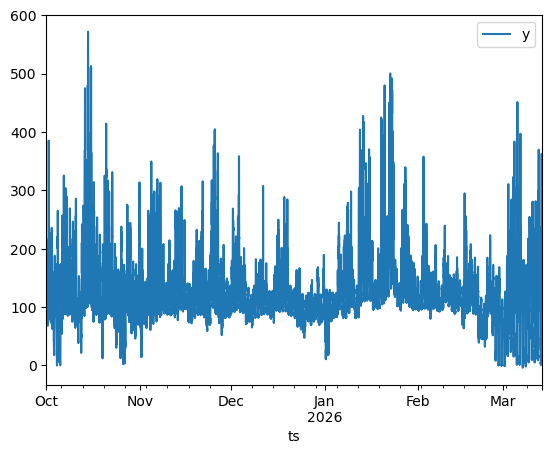

In [18]:
df[["y"]].plot()
#Missing ENTO-E data

In [19]:
# -------------------------------
# 3) Create time-based train/test split (block split)
# -------------------------------
# We split by DAY to avoid leakage across intra-day adjacency.
df["day"] = df.index.normalize()

all_days = np.array(sorted(df["day"].unique()))
if len(all_days) < (MIN_TRAIN_DAYS + TEST_DAYS):
    raise ValueError(
        f"Not enough post-breakpoint days for robust validation. "
        f"Have {len(all_days)} days, need at least {MIN_TRAIN_DAYS + TEST_DAYS}."
    )

test_days = all_days[-TEST_DAYS:]
train_days = all_days[:-TEST_DAYS]

train = df[df["day"].isin(train_days)].copy()
test  = df[df["day"].isin(test_days)].copy()

In [20]:
train

,y,hour_ts,y_hour,hod,dow,month,is_weekend,hour_ramp_1,hour_ramp_24,q_in_hour,qod,delta_true,day
ts,,,,,,,,,,,,,
2025-10-01 00:00:00+02:00,108.98,2025-10-01 00:00:00+02:00,96.9075,0,2,10,0,NaN,NaN,0,0,12.0725,2025-10-01 00:00:00+02:00
2025-10-01 00:15:00+02:00,97.08,2025-10-01 00:00:00+02:00,96.9075,0,2,10,0,NaN,NaN,1,1,0.1725,2025-10-01 00:00:00+02:00
2025-10-01 00:30:00+02:00,90.97,2025-10-01 00:00:00+02:00,96.9075,0,2,10,0,NaN,NaN,2,2,-5.9375,2025-10-01 00:00:00+02:00
2025-10-01 00:45:00+02:00,90.60,2025-10-01 00:00:00+02:00,96.9075,0,2,10,0,NaN,NaN,3,3,-6.3075,2025-10-01 00:00:00+02:00
2025-10-01 01:00:00+02:00,91.15,2025-10-01 01:00:00+02:00,88.7800,1,2,10,0,-8.1275,NaN,0,4,2.3700,2025-10-01 00:00:00+02:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-11 22:45:00+01:00,106.26,2026-02-11 22:00:00+01:00,110.4425,22,2,2,0,-3.9975,-9.2850,3,91,-4.1825,2026-02-11 00:00:00+01:00
2026-02-11 23:00:00+01:00,110.38,2026-02-11 23:00:00+01:00,103.6750,23,2,2,0,-6.7675,-4.2375,0,92,6.7050,2026-02-11 00:00:00+01:00
2026-02-11 23:15:00+01:00,105.49,2026-02-11 23:00:00+01:00,103.6750,23,2,2,0,-6.7675,-4.2375,1,93,1.8150,2026-02-11 00:00:00+01:00


In [21]:
test

,y,hour_ts,y_hour,hod,dow,month,is_weekend,hour_ramp_1,hour_ramp_24,q_in_hour,qod,delta_true,day
ts,,,,,,,,,,,,,
2026-02-12 00:00:00+01:00,96.36,2026-02-12 00:00:00+01:00,95.6525,0,3,2,0,-8.0225,-7.5075,0,0,0.7075,2026-02-12 00:00:00+01:00
2026-02-12 00:15:00+01:00,94.85,2026-02-12 00:00:00+01:00,95.6525,0,3,2,0,-8.0225,-7.5075,1,1,-0.8025,2026-02-12 00:00:00+01:00
2026-02-12 00:30:00+01:00,96.79,2026-02-12 00:00:00+01:00,95.6525,0,3,2,0,-8.0225,-7.5075,2,2,1.1375,2026-02-12 00:00:00+01:00
2026-02-12 00:45:00+01:00,94.61,2026-02-12 00:00:00+01:00,95.6525,0,3,2,0,-8.0225,-7.5075,3,3,-1.0425,2026-02-12 00:00:00+01:00
2026-02-12 01:00:00+01:00,96.36,2026-02-12 01:00:00+01:00,95.8075,1,3,2,0,0.1550,-6.9175,0,4,0.5525,2026-02-12 00:00:00+01:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,116.90,2026-03-13 22:00:00+01:00,124.9150,22,4,3,0,-9.0675,-22.1850,3,91,-8.0150,2026-03-13 00:00:00+01:00
2026-03-13 23:00:00+01:00,133.69,2026-03-13 23:00:00+01:00,116.9375,23,4,3,0,-7.9775,-9.0400,0,92,16.7525,2026-03-13 00:00:00+01:00
2026-03-13 23:15:00+01:00,115.61,2026-03-13 23:00:00+01:00,116.9375,23,4,3,0,-7.9775,-9.0400,1,93,-1.3275,2026-03-13 00:00:00+01:00


In [22]:
X_train = train[FEATURES]
y_train = train["delta_true"]

X_test  = test[FEATURES]
y_test  = test["delta_true"]

# Model: LightGBM if available, else sklearn GradientBoostingRegressor
model_name = None
model = None

model_name = "LightGBM"
model = lgb.LGBMRegressor(
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=64,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
    )
model.fit(X_train, y_train)

# Predict deltas, reconstruct 15-min prices
test = test.copy()
test["delta_hat"] = model.predict(X_test)
test["y_hat"] = test["y_hour"] + test["delta_hat"]
test

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001739 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 808
[LightGBM] [Info] Number of data points in the train set: 12868, number of used features: 8
[LightGBM] [Info] Start training from score -0.000000


,y,hour_ts,y_hour,hod,dow,month,is_weekend,hour_ramp_1,hour_ramp_24,q_in_hour,qod,delta_true,day,delta_hat,y_hat
ts,,,,,,,,,,,,,,,
2026-02-12 00:00:00+01:00,96.36,2026-02-12 00:00:00+01:00,95.6525,0,3,2,0,-8.0225,-7.5075,0,0,0.7075,2026-02-12 00:00:00+01:00,4.067324,99.719824
2026-02-12 00:15:00+01:00,94.85,2026-02-12 00:00:00+01:00,95.6525,0,3,2,0,-8.0225,-7.5075,1,1,-0.8025,2026-02-12 00:00:00+01:00,1.322247,96.974747
2026-02-12 00:30:00+01:00,96.79,2026-02-12 00:00:00+01:00,95.6525,0,3,2,0,-8.0225,-7.5075,2,2,1.1375,2026-02-12 00:00:00+01:00,-1.609177,94.043323
2026-02-12 00:45:00+01:00,94.61,2026-02-12 00:00:00+01:00,95.6525,0,3,2,0,-8.0225,-7.5075,3,3,-1.0425,2026-02-12 00:00:00+01:00,-3.240718,92.411782
2026-02-12 01:00:00+01:00,96.36,2026-02-12 01:00:00+01:00,95.8075,1,3,2,0,0.1550,-6.9175,0,4,0.5525,2026-02-12 00:00:00+01:00,1.526242,97.333742
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,116.90,2026-03-13 22:00:00+01:00,124.9150,22,4,3,0,-9.0675,-22.1850,3,91,-8.0150,2026-03-13 00:00:00+01:00,-9.338510,115.576490
2026-03-13 23:00:00+01:00,133.69,2026-03-13 23:00:00+01:00,116.9375,23,4,3,0,-7.9775,-9.0400,0,92,16.7525,2026-03-13 00:00:00+01:00,8.676935,125.614435
2026-03-13 23:15:00+01:00,115.61,2026-03-13 23:00:00+01:00,116.9375,23,4,3,0,-7.9775,-9.0400,1,93,-1.3275,2026-03-13 00:00:00+01:00,3.678477,120.615977


In [23]:
mae = mean_absolute_error(test["y"], test["y_hat"])
rmse = float(np.sqrt(mean_squared_error(test["y"], test["y_hat"])))

# Quarter-wise errors
test["abs_err"] = (test["y"] - test["y_hat"]).abs()
mae_by_q = test.groupby("q_in_hour")["abs_err"].mean().rename("MAE")

# Spike subset: evaluate on top 1% true prices (heavy-tail behavior)
thr = test["y"].quantile(0.99)
spike = test[test["y"] >= thr]
spike_mae = mean_absolute_error(spike["y"], spike["y_hat"]) if len(spike) else np.nan
spike_rmse = float(np.sqrt(mean_squared_error(spike["y"], spike["y_hat"]))) if len(spike) else np.nan

# Distribution check (quantiles)
q_levels = [0.01, 0.05, 0.5, 0.95, 0.99]
true_q = test["y"].quantile(q_levels)
hat_q  = test["y_hat"].quantile(q_levels)
quantile_compare = pd.DataFrame({"true": true_q, "recon": hat_q})
quantile_compare.index.name = "quantile"

print("\n============================")
print("PHASE 2: Proxy reconstruction validation (hourly → 15-min)")
print("============================")
print(f"Model: {model_name}")
print(f"Train days: {train_days[0].date()} → {train_days[-1].date()}  ({len(train_days)} days)")
print(f"Test  days: {test_days[0].date()} → {test_days[-1].date()}   ({len(test_days)} days)")
print(f"\nOverall MAE : {mae:.4f}")
print(f"Overall RMSE: {rmse:.4f}")
print("\nMAE by quarter-in-hour (0..3):")
print(mae_by_q)

print("\nSpike subset (top 1% of TRUE prices in test):")
print(f"Threshold (99th pct): {thr:.3f}")
print(f"Spike count: {len(spike)}")
print(f"Spike MAE : {spike_mae:.4f}")
print(f"Spike RMSE: {spike_rmse:.4f}")

print("\nQuantile comparison (TRUE vs reconstructed):")
print(quantile_compare)

# Optional: error by quarter-of-day (shape quality across day)
mae_by_qod = test.groupby("qod")["abs_err"].mean()
print("\nMAE by quarter-of-day computed (length):", len(mae_by_qod))


PHASE 2: Proxy reconstruction validation (hourly → 15-min)
Model: LightGBM
Train days: 2025-10-01 → 2026-02-11  (134 days)
Test  days: 2026-02-12 → 2026-03-13   (30 days)

Overall MAE : 6.1438
Overall RMSE: 11.5045

MAE by quarter-in-hour (0..3):
q_in_hour
0    7.413763
1    4.668868
2    4.419870
3    8.072663
Name: MAE, dtype: float64

Spike subset (top 1% of TRUE prices in test):
Threshold (99th pct): 267.942
Spike count: 29
Spike MAE : 39.0664
Spike RMSE: 50.5582

Quantile comparison (TRUE vs reconstructed):
              true       recon
quantile                      
0.01       -0.2084   -1.963450
0.05        8.6445    9.978739
0.50      106.0700  106.629375
0.95      192.7455  189.237265
0.99      267.9416  266.521245

MAE by quarter-of-day computed (length): 96


In [24]:
# -----------------------
# Helper: DST-safe hour bucket key for 15-min timestamps
# -----------------------
def hour_bucket_local(idx: pd.DatetimeIndex, tz: str = TZ) -> pd.DatetimeIndex:
    """Return hour bucket timestamps in local tz, computed by flooring in UTC (DST-safe)."""
    return idx.tz_convert("UTC").floor("H").tz_convert(tz)

In [25]:
# -----------------------
# 1) Build training set from TRUE 15-min data (post-breakpoint)
# -----------------------
g = PHASE1_GRID.copy()
g = g[g["is_observed"]].copy()

# Prefer the true 15-min post-breakpoint part
if "resolution" in g.columns:
    g15 = g[(g.index >= BREAKPOINT) & (g["resolution"] == "15min")].copy()
else:
    g15 = g[g.index >= BREAKPOINT].copy()

g15 = g15.sort_index()
g15 = g15[["y"]].dropna()

if g15.empty:
    raise ValueError("No observed 15-min data found after 2025-10-01. Check Phase 1 grid and breakpoint.")

# Hourly mean series derived from TRUE 15-min (simulated hourly-only)
hour = g15["y"].resample("1H").mean().to_frame("y_hour")
hour["hod"] = hour.index.hour.astype(int)
hour["dow"] = hour.index.dayofweek.astype(int)
hour["month"] = hour.index.month.astype(int)
hour["is_weekend"] = (hour["dow"] >= 5).astype(int)
hour["hour_ramp_1"] = hour["y_hour"].diff(1)
hour["hour_ramp_24"] = hour["y_hour"].diff(24)

# Align hourly-only info to each 15-min timestamp
train_df = g15.copy()
train_df["hour_ts"] = hour_bucket_local(train_df.index)  # DST-safe hour key
train_df = train_df.join(hour, on="hour_ts", how="left")

train_df["q_in_hour"] = (train_df.index.minute // 15).astype(int)  # 0..3
train_df["delta_true"] = train_df["y"] - train_df["y_hour"]

FEATURES = [
    "y_hour", "hour_ramp_1", "hour_ramp_24",
    "hod", "dow", "month", "is_weekend",
    "q_in_hour",
]

train_df = train_df.dropna(subset=FEATURES + ["delta_true"]).copy()

In [26]:
def fit_quantile(alpha: float):
    m = lgb.LGBMRegressor(
        objective="quantile",
        alpha=alpha,
        n_estimators=1400,
        learning_rate=0.03,
        num_leaves=64,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
    )
    m.fit(train_df[FEATURES], train_df["delta_true"])
    return m

q10_model = fit_quantile(0.10)
q50_model = fit_quantile(0.50)  # use as point estimate (robust)
q90_model = fit_quantile(0.90)

PHASE3_QMODELS = {"p10": q10_model, "p50": q50_model, "p90": q90_model}
PHASE3_FEATURES = FEATURES

print("Phase 3: trained quantile disaggregation models on post-breakpoint TRUE 15-min data.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000320 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 809
[LightGBM] [Info] Number of data points in the train set: 15652, number of used features: 8
[LightGBM] [Info] Start training from score -14.616500
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000243 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 809
[LightGBM] [Info] Number of data points in the train set: 15652, number of used features: 8
[LightGBM] [Info] Start training from score -0.091250
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000269 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough

In [27]:
PHASE1_RAW

,start,end,y,source_file,delta_min,resolution
0,2023-01-01 00:00:00+01:00,2023-01-01 01:00:00+01:00,19.76,Entso_e\DA_price\GUI_ENERGY_PRICES_20221231230...,60.0,60min
1,2023-01-01 01:00:00+01:00,2023-01-01 02:00:00+01:00,0.19,Entso_e\DA_price\GUI_ENERGY_PRICES_20221231230...,60.0,60min
2,2023-01-01 02:00:00+01:00,2023-01-01 03:00:00+01:00,0.07,Entso_e\DA_price\GUI_ENERGY_PRICES_20221231230...,60.0,60min
3,2023-01-01 03:00:00+01:00,2023-01-01 04:00:00+01:00,0.01,Entso_e\DA_price\GUI_ENERGY_PRICES_20221231230...,60.0,60min
4,2023-01-01 04:00:00+01:00,2023-01-01 05:00:00+01:00,-0.77,Entso_e\DA_price\GUI_ENERGY_PRICES_20221231230...,60.0,60min
...,...,...,...,...,...,...
59491,2026-03-13 22:45:00+01:00,2026-03-13 23:00:00+01:00,116.90,Entso_e\DA_price\GUI_ENERGY_PRICES_20251231230...,15.0,15min
59492,2026-03-13 23:00:00+01:00,2026-03-13 23:15:00+01:00,133.69,Entso_e\DA_price\GUI_ENERGY_PRICES_20251231230...,15.0,15min
59493,2026-03-13 23:15:00+01:00,2026-03-13 23:30:00+01:00,115.61,Entso_e\DA_price\GUI_ENERGY_PRICES_20251231230...,15.0,15min
59494,2026-03-13 23:30:00+01:00,2026-03-13 23:45:00+01:00,115.10,Entso_e\DA_price\GUI_ENERGY_PRICES_20251231230...,15.0,15min


In [28]:
# -----------------------
# 3) Extract PRE-breakpoint hourly observations (the thing we backcast from)
# -----------------------
raw = PHASE1_RAW.copy()

# Determine hourly rows: delta_min ~ 60 and start < breakpoint
if "delta_min" not in raw.columns:
    raw["delta_min"] = (raw["end"] - raw["start"]).dt.total_seconds() / 60.0
    
pre_hour = raw[(raw["start"] < BREAKPOINT)].copy()
pre_hour = pre_hour.sort_values("start")

if pre_hour.empty:
    raise ValueError(
        "No pre-breakpoint hourly observations found (delta_min≈60). "
        "If your pre-breakpoint data is not hourly in PHASE1_RAW, check Phase 1 ingestion."
    )

# Create hourly series
pre_hour = pre_hour.set_index("start")[["y"]].rename(columns={"y": "y_hour"})
pre_hour.index.name = "hour_ts"

# Build a continuous hourly index (DST-safe): do in UTC then convert back
hour_utc = pd.date_range(
    pre_hour.index.min().tz_convert("UTC"),
    pre_hour.index.max().tz_convert("UTC"),
    freq="1H",
    tz="UTC",
)
hour_local = hour_utc.tz_convert(TZ)

pre_hour = pre_hour.reindex(hour_local)
pre_hour["is_hour_observed"] = pre_hour["y_hour"].notna()

# For backcasting we typically need all hours; if there are gaps, we can:
# - leave them NaN (synthetic will be NaN for those hours)
# - or interpolate hourly. For publication safety, default to NO interpolation.
# If you want interpolation, do it explicitly and document it.

# Hourly features
pre_hour["hod"] = pre_hour.index.hour.astype(int)
pre_hour["dow"] = pre_hour.index.dayofweek.astype(int)
pre_hour["month"] = pre_hour.index.month.astype(int)
pre_hour["is_weekend"] = (pre_hour["dow"] >= 5).astype(int)
pre_hour["hour_ramp_1"] = pre_hour["y_hour"].diff(1)
pre_hour["hour_ramp_24"] = pre_hour["y_hour"].diff(24)

In [29]:
pre_hour

,y_hour,is_hour_observed,hod,dow,month,is_weekend,hour_ramp_1,hour_ramp_24
2023-01-01 00:00:00+01:00,19.76,True,0,6,1,1,NaN,NaN
2023-01-01 01:00:00+01:00,0.19,True,1,6,1,1,-19.57,NaN
2023-01-01 02:00:00+01:00,0.07,True,2,6,1,1,-0.12,NaN
2023-01-01 03:00:00+01:00,0.01,True,3,6,1,1,-0.06,NaN
2023-01-01 04:00:00+01:00,-0.77,True,4,6,1,1,-0.78,NaN
...,...,...,...,...,...,...,...,...
2025-09-30 19:00:00+02:00,370.11,True,19,1,9,0,20.05,-54.35
2025-09-30 20:00:00+02:00,192.89,True,20,1,9,0,-177.22,18.65
2025-09-30 21:00:00+02:00,141.91,True,21,1,9,0,-50.98,6.46
2025-09-30 22:00:00+02:00,124.01,True,22,1,9,0,-17.90,6.13


In [30]:
# -----------------------
# 4) Expand each hour into 4 quarters (DST-safe, generate in UTC then convert)
# -----------------------
# Create quarter timestamps for each hour in UTC, then convert to local tz
pre_hour_utc = pre_hour.index.tz_convert("UTC")

quarters_utc = []
q_in_hour = []
hour_key_utc = []

for q, minutes in enumerate([0, 15, 30, 45]):
    quarters_utc.append(pre_hour_utc + pd.Timedelta(minutes=minutes))
    q_in_hour.append(np.full(len(pre_hour_utc), q, dtype=int))
    hour_key_utc.append(pre_hour_utc)  # hour bucket key in UTC

quarters_utc = pd.DatetimeIndex(np.concatenate(quarters_utc))
q_in_hour = np.concatenate(q_in_hour)
hour_key_utc = pd.DatetimeIndex(np.concatenate(hour_key_utc))

synthetic = pd.DataFrame({
    "ts_utc": quarters_utc,
    "hour_ts_utc": hour_key_utc,
    "q_in_hour": q_in_hour
}).sort_values("ts_utc")

# Convert to local tz for final index
synthetic["ts"] = synthetic["ts_utc"].dt.tz_convert(TZ)
synthetic["hour_ts"] = synthetic["hour_ts_utc"].dt.tz_convert(TZ)

# Join hourly features/price onto each quarter
synthetic = synthetic.join(pre_hour, on="hour_ts", how="left")

# Prepare feature matrix and predict delta quantiles
X_syn = synthetic[FEATURES]

# Predict deltas (will be NaN where hourly y_hour is NaN)
synthetic["delta_p10"] = np.where(
    synthetic["y_hour"].notna(),
    q10_model.predict(X_syn),
    np.nan
)
synthetic["delta_p50"] = np.where(
    synthetic["y_hour"].notna(),
    q50_model.predict(X_syn),
    np.nan
)
synthetic["delta_p90"] = np.where(
    synthetic["y_hour"].notna(),
    q90_model.predict(X_syn),
    np.nan
)

# Reconstruct price quantiles
synthetic["y_p10"] = synthetic["y_hour"] + synthetic["delta_p10"]
synthetic["y_p50"] = synthetic["y_hour"] + synthetic["delta_p50"]  # point estimate
synthetic["y_p90"] = synthetic["y_hour"] + synthetic["delta_p90"]

synthetic["is_synthetic"] = 1
synthetic["is_observed"] = 0

# Keep clean output
SYNTH_15M_PRE = synthetic.set_index("ts")[["y_p10", "y_p50", "y_p90", "is_synthetic", "is_observed"]].sort_index()

print("Phase 3: generated pre-breakpoint synthetic 15-min series with P10/P50/P90.")
print("Synthetic range:", SYNTH_15M_PRE.index.min(), "→", SYNTH_15M_PRE.index.max())
print("Synthetic rows:", len(SYNTH_15M_PRE))
print(SYNTH_15M_PRE)

Phase 3: generated pre-breakpoint synthetic 15-min series with P10/P50/P90.
Synthetic range: 2023-01-01 00:00:00+01:00 → 2025-09-30 23:45:00+02:00
Synthetic rows: 96380
                                y_p10       y_p50       y_p90  is_synthetic  \
ts                                                                            
2023-01-01 00:00:00+01:00   17.502657   26.058070   32.408854             1   
2023-01-01 00:15:00+01:00   15.392896   19.839492   26.449537             1   
2023-01-01 00:30:00+01:00   13.731952   16.534288   23.981565             1   
2023-01-01 00:45:00+01:00    8.247812   14.021324   22.101374             1   
2023-01-01 01:00:00+01:00   -0.269396    1.317738    9.766121             1   
...                               ...         ...         ...           ...   
2025-09-30 22:45:00+02:00  108.720279  109.886190  116.596733             1   
2025-09-30 23:00:00+02:00  114.020208  118.289558  124.706993             1   
2025-09-30 23:15:00+02:00  107.279735  11

In [31]:
# -----------------------
# 5) (Optional) Build unified 15-min dataset: pre synthetic + post real
# -----------------------
# Use P50 as the single point price for synthetic history.
POST_REAL_15M = PHASE1_GRID.loc[PHASE1_GRID["is_observed"] & (PHASE1_GRID.index >= BREAKPOINT), ["y"]].copy()
POST_REAL_15M = POST_REAL_15M.rename(columns={"y": "y_real"})
POST_REAL_15M["is_synthetic"] = 0
POST_REAL_15M["is_observed"] = 1

# Create a unified point series "y_point" (synthetic uses y_p50; real uses y_real)
pre_point = SYNTH_15M_PRE.copy()
pre_point["y_point"] = pre_point["y_p50"]

post_point = POST_REAL_15M.copy()
post_point["y_point"] = post_point["y_real"]
post_point["y_p10"] = np.nan
post_point["y_p50"] = np.nan
post_point["y_p90"] = np.nan

UNIFIED_15M = pd.concat([
    pre_point[["y_point", "y_p10", "y_p50", "y_p90", "is_synthetic", "is_observed"]],
    post_point[["y_point", "y_p10", "y_p50", "y_p90", "is_synthetic", "is_observed"]],
]).sort_index()

PHASE3_SYNTH_15M_PRE = SYNTH_15M_PRE
PHASE3_UNIFIED_15M = UNIFIED_15M

print("\nPhase 3 complete. Objects in memory:")
print(" - PHASE3_QMODELS (dict of quantile models)")
print(" - PHASE3_SYNTH_15M_PRE (pre-breakpoint synthetic 15-min with P10/P50/P90)")
print(" - PHASE3_UNIFIED_15M (unified 15-min point series + bands where available)")
PHASE3_UNIFIED_15M


Phase 3 complete. Objects in memory:
 - PHASE3_QMODELS (dict of quantile models)
 - PHASE3_SYNTH_15M_PRE (pre-breakpoint synthetic 15-min with P10/P50/P90)
 - PHASE3_UNIFIED_15M (unified 15-min point series + bands where available)


,y_point,y_p10,y_p50,y_p90,is_synthetic,is_observed
ts,,,,,,
2023-01-01 00:00:00+01:00,26.058070,17.502657,26.058070,32.408854,1,0
2023-01-01 00:15:00+01:00,19.839492,15.392896,19.839492,26.449537,1,0
2023-01-01 00:30:00+01:00,16.534288,13.731952,16.534288,23.981565,1,0
2023-01-01 00:45:00+01:00,14.021324,8.247812,14.021324,22.101374,1,0
2023-01-01 01:00:00+01:00,1.317738,-0.269396,1.317738,9.766121,1,0
...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,116.900000,NaN,NaN,NaN,0,1
2026-03-13 23:00:00+01:00,133.690000,NaN,NaN,NaN,0,1
2026-03-13 23:15:00+01:00,115.610000,NaN,NaN,NaN,0,1


In [32]:
df[df.index.duplicated()]

,y,hour_ts,y_hour,hod,dow,month,is_weekend,hour_ramp_1,hour_ramp_24,q_in_hour,qod,delta_true,day
ts,,,,,,,,,,,,,


In [33]:
# ----------------------------
# Load parsing helpers (CET/CEST label -> unambiguous instant)
# ----------------------------
def parse_dt_with_label(s: str, file_type: str) -> pd.Timestamp:
    """
    Input: '31/03/2024 01:00:00 (CET)' or '(CEST)'
    Return: tz-aware timestamp in Europe/Budapest (as an instant).
    """
    s = s.strip()
    m = re.match(r"^(.*?)(?:\s+\((CET|CEST)\))?$", s)
    if not m:
        raise ValueError(f"Unrecognized datetime format: {s}")
    dt_part = m.group(1).strip()
    label = m.group(2)

    if file_type == "load":
        dt = pd.to_datetime(dt_part, format="%d/%m/%Y %H:%M", errors="raise")
    elif file_type == "renew":
        dt = pd.to_datetime(dt_part, format="%d/%m/%Y %H:%M:%S", errors="raise")

    if label is None:
        # fallback: attach TZ conservatively (rare for ENTSO-E exports)
        return dt.tz_localize(TZ, ambiguous="NaT", nonexistent="shift_forward")

    offset_hours = 1 if label == "CET" else 2  # CET=UTC+1, CEST=UTC+2
    utc = (dt - pd.Timedelta(hours=offset_hours)).tz_localize("UTC")
    return utc.tz_convert(TZ)

def parse_mtu_start_load(mtu: str) -> pd.Timestamp:
    # "dd/mm/YYYY HH:MM:SS (CET) - dd/mm/YYYY HH:MM:SS (CET)"
    a = mtu.split("-")[0].strip()
    return parse_dt_with_label(a, file_type="load")

def parse_mtu_start_renew(mtu: str) -> pd.Timestamp:
    # "dd/mm/YYYY HH:MM:SS (CET) - dd/mm/YYYY HH:MM:SS (CET)"
    a = mtu.split("-")[0].strip()
    return parse_dt_with_label(a, file_type="renew")

def pick_load_col(df: pd.DataFrame) -> str:
    # Try common ENTSO-E export column names
    print(df)
    candidates = [
        "Total Load Forecast (MW)",
        "Total Load Forecast (MWh)",
        "Total Load Forecast (MW )",
        "Total Load (MW)",
        "Value",
    ]
    for c in candidates:
        if c in df.columns:
            return c
    # fallback: pick first numeric-like column not MTU/Area
    non = {MTU_COL, "Area", "Bidding Zone", "Country"}
    for c in df.columns:
        if c in non: 
            continue
        if df[c].dtype != object:
            return c
    raise ValueError(f"Could not identify load column. Columns: {list(df.columns)}")

#Load Forecast

def load_total_load_forecast(paths) -> pd.Series:
    parts = []
    for p in paths:
        df = pd.read_csv(p)
        if MTU_COL not in df.columns:
            raise ValueError(f"Missing '{MTU_COL}' in {p}")

        # Filter HU if applicable
        if "Area" in df.columns:
            hu_mask = df["Area"].astype(str).str.contains(r"\bHU\b|Hungary", case=False, na=False)
            if hu_mask.any():
                df = df.loc[hu_mask].copy()
        col = "Day-ahead Total Load Forecast (MW)"

        ts = df[MTU_COL].astype(str).map(parse_mtu_start_load)
        vals = pd.to_numeric(df[col], errors="coerce")

        tmp = pd.DataFrame({"ts": ts, "load_fc": vals}).dropna()
        parts.append(tmp)

    all_df = pd.concat(parts, ignore_index=True).drop_duplicates(subset=["ts"]).sort_values("ts")
    s = all_df.set_index("ts")["load_fc"].sort_index()
    return s
def load_total_generation_forecast(paths) ->pd.Series:
    parts = []
    for p in paths:
        df = pd.read_csv(p)
        if MTU_COL not in df.columns:
            raise ValueError(f"Missing '{MTU_COL}' in {p}")

        # Filter HU if applicable
        if "Area" in df.columns:
            hu_mask = df["Area"].astype(str).str.contains(r"\bHU\b|Hungary", case=False, na=False)
            if hu_mask.any():
                df = df.loc[hu_mask].copy()
        
        col = "Generation Forecast (MW)"
        ts = df[MTU_COL].astype(str).map(parse_mtu_start_renew)
        vals = pd.to_numeric(df[col], errors="coerce")

        tmp = pd.DataFrame({"ts": ts, "renew_fc": vals}).dropna()
        parts.append(tmp)

    all_df = pd.concat(parts, ignore_index=True).drop_duplicates(subset=["ts"]).sort_values("ts")
    s = all_df.set_index("ts")["renew_fc"].sort_index()
    return s

def load_renewables_forecast(paths, renew_type: str) ->pd.Series:
    parts = []
    for p in paths:
        df = pd.read_csv(p)
        if MTU_COL not in df.columns:
            raise ValueError(f"Missing '{MTU_COL}' in {p}")

        # Filter HU if applicable
        if "Area" in df.columns:
            hu_mask = df["Area"].astype(str).str.contains(r"\bHU\b|Hungary", case=False, na=False)
            if hu_mask.any():
                df = df.loc[hu_mask].copy()
        col = "Day-ahead (MW)"
        ts = df[MTU_COL].astype(str).map(parse_mtu_start_renew)
        vals = pd.to_numeric(df[col], errors="coerce")
        if renew_type == "solar":
            tmp = pd.DataFrame({"ts": ts, "renew_fc_solar": vals}).dropna()
        elif renew_type == "wind":
            tmp = pd.DataFrame({"ts": ts, "renew_fc_wind": vals}).dropna()
        parts.append(tmp)

    all_df = pd.concat(parts, ignore_index=True).drop_duplicates(subset=["ts"]).sort_values("ts")
    if renew_type == "solar":
        s = all_df.set_index("ts")["renew_fc_solar"].sort_index()
    elif renew_type == "wind":
        s = all_df.set_index("ts")["renew_fc_wind"].sort_index()
    return s

In [34]:
load_fc = load_total_load_forecast(LOAD_FILES)
print("Loaded load forecast:", load_fc.index.min(), "→", load_fc.index.max(), "rows:", len(load_fc))
print(load_fc)

Loaded load forecast: 2023-01-01 00:00:00+01:00 → 2026-03-14 23:45:00+01:00 rows: 112224
ts
2023-01-01 00:00:00+01:00    4035.83
2023-01-01 00:15:00+01:00    3995.62
2023-01-01 00:30:00+01:00    3936.79
2023-01-01 00:45:00+01:00    3835.57
2023-01-01 01:00:00+01:00    3785.74
                              ...   
2026-03-14 22:45:00+01:00    4658.82
2026-03-14 23:00:00+01:00    4609.15
2026-03-14 23:15:00+01:00    4557.74
2026-03-14 23:30:00+01:00    4503.15
2026-03-14 23:45:00+01:00    4445.40
Name: load_fc, Length: 112224, dtype: float64


In [35]:
renewables_solar_fc = load_renewables_forecast(RENEWABLES_FILES_SOLAR, "solar")
print("Loaded load forecast:", renewables_solar_fc.index.min(), "→", renewables_solar_fc.index.max(), "rows:", len(renewables_solar_fc))
print(renewables_solar_fc)

Loaded load forecast: 2023-01-01 00:00:00+01:00 → 2026-03-13 23:45:00+01:00 rows: 112128
ts
2023-01-01 00:00:00+01:00    0.0
2023-01-01 00:15:00+01:00    0.0
2023-01-01 00:30:00+01:00    0.0
2023-01-01 00:45:00+01:00    0.0
2023-01-01 01:00:00+01:00    0.0
                            ... 
2026-03-13 22:45:00+01:00    0.0
2026-03-13 23:00:00+01:00    0.0
2026-03-13 23:15:00+01:00    0.0
2026-03-13 23:30:00+01:00    0.0
2026-03-13 23:45:00+01:00    0.0
Name: renew_fc_solar, Length: 112128, dtype: float64


In [36]:
renewables_wind_fc = load_renewables_forecast(RENEWABLES_FILES_WIND, "wind")
print("Loaded load forecast:", renewables_wind_fc.index.min(), "→", renewables_wind_fc.index.max(), "rows:", len(renewables_wind_fc))
print(renewables_wind_fc)

Loaded load forecast: 2023-01-01 00:00:00+01:00 → 2026-03-13 23:45:00+01:00 rows: 112128
ts
2023-01-01 00:00:00+01:00     93.57
2023-01-01 00:15:00+01:00     89.91
2023-01-01 00:30:00+01:00     86.26
2023-01-01 00:45:00+01:00     82.60
2023-01-01 01:00:00+01:00     80.49
                              ...  
2026-03-13 22:45:00+01:00    114.80
2026-03-13 23:00:00+01:00    116.84
2026-03-13 23:15:00+01:00    118.89
2026-03-13 23:30:00+01:00    120.92
2026-03-13 23:45:00+01:00    122.95
Name: renew_fc_wind, Length: 112128, dtype: float64


In [37]:
total_generation_fc = load_total_generation_forecast(TOTALGENERATION_FILES)
print("Loaded load forecast:", total_generation_fc.index.min(), "→", total_generation_fc.index.max(), "rows:", len(total_generation_fc))
print(total_generation_fc)

Loaded load forecast: 2023-01-01 00:00:00+01:00 → 2026-03-13 23:45:00+01:00 rows: 112128
ts
2023-01-01 00:00:00+01:00    2845.97
2023-01-01 00:15:00+01:00    2818.03
2023-01-01 00:30:00+01:00    2815.99
2023-01-01 00:45:00+01:00    2816.93
2023-01-01 01:00:00+01:00    2821.69
                              ...   
2026-03-13 22:45:00+01:00    2851.44
2026-03-13 23:00:00+01:00    2783.15
2026-03-13 23:15:00+01:00    2762.48
2026-03-13 23:30:00+01:00    2746.49
2026-03-13 23:45:00+01:00    2731.60
Name: renew_fc, Length: 112128, dtype: float64


In [38]:
# ----------------------------
# 1) Prepare unified series
# ----------------------------
u = PHASE3_UNIFIED_15M.copy().sort_index()
need_cols = {"y_point", "is_synthetic", "is_observed"}
missing = need_cols - set(u.columns)
if missing:
    raise ValueError(f"PHASE3_UNIFIED_15M missing columns: {missing}")
u["load_fc"] = load_fc.reindex(u.index)
u["generation_fc"] = total_generation_fc.reindex(u.index)
u["renewables_solar_fc"] = renewables_solar_fc.reindex(u.index)
u["renewables_wind_fc"] = renewables_wind_fc.reindex(u.index)
# Ensure index tz-aware in Budapest
if u.index.tz is None:
    raise ValueError("PHASE3_UNIFIED_15M index must be tz-aware (Europe/Budapest).")

In [39]:
u

,y_point,y_p10,y_p50,y_p90,is_synthetic,is_observed,load_fc,generation_fc,renewables_solar_fc,renewables_wind_fc
ts,,,,,,,,,,
2023-01-01 00:00:00+01:00,26.058070,17.502657,26.058070,32.408854,1,0,4035.83,2845.97,0.0,93.57
2023-01-01 00:15:00+01:00,19.839492,15.392896,19.839492,26.449537,1,0,3995.62,2818.03,0.0,89.91
2023-01-01 00:30:00+01:00,16.534288,13.731952,16.534288,23.981565,1,0,3936.79,2815.99,0.0,86.26
2023-01-01 00:45:00+01:00,14.021324,8.247812,14.021324,22.101374,1,0,3835.57,2816.93,0.0,82.60
2023-01-01 01:00:00+01:00,1.317738,-0.269396,1.317738,9.766121,1,0,3785.74,2821.69,0.0,80.49
...,...,...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,116.900000,NaN,NaN,NaN,0,1,5127.60,2851.44,0.0,114.80
2026-03-13 23:00:00+01:00,133.690000,NaN,NaN,NaN,0,1,5081.26,2783.15,0.0,116.84
2026-03-13 23:15:00+01:00,115.610000,NaN,NaN,NaN,0,1,5024.79,2762.48,0.0,118.89


In [40]:
# ----------------------------
# 1) Build "daily cutoff table": one row per day with state features at t0 = day-1 23:45
#    and targets: the 96 prices for that day
# ----------------------------
def day_horizon_index(day: pd.Timestamp) -> pd.DatetimeIndex:
    """Return the 96 timestamps for a given local day (00:00..23:45)."""
    start = pd.Timestamp(day)
    return pd.date_range(start, start + pd.Timedelta(hours=24) - pd.Timedelta(minutes=15),
                         freq="15min", tz=TZ)

In [41]:
def compute_state_features_at_t0(series: pd.Series, t0: pd.Timestamp) -> dict:
    """
    Compute state features using only history up to and including t0.
    series: y_point indexed by 15-min timestamps
    """
    feats = {}
    y0 = series.loc[:t0]
    feats["last_y"] = float(y0.iloc[-1])
    # Lags at cutoff
    for L in STATE_LAGS:
        key = f"lag_{L}_t0"
        feats[key] = float(y0.iloc[-(L+1)])  # because y0.iloc[-1] is t0

    # Ramps at cutoff (examples)
    feats["ramp_1h_t0"] = feats["last_y"] - feats["lag_4_t0"]
    feats["ramp_6h_t0"] = feats["last_y"] - feats["lag_24_t0"]
    feats["ramp_1d_t0"] = feats["last_y"] - feats["lag_96_t0"]

    # Rolling stats ending at t0 (past values including t0)
    yvals = y0.values
    for w in STATE_ROLL_WINS:
        window = yvals[-w:]
        feats[f"roll_mean_{w}_t0"] = float(np.mean(window))
        feats[f"roll_std_{w}_t0"] = float(np.std(window, ddof=1)) if w > 1 else 0.0

    return feats

In [42]:
def build_daily_dataset(u_df: pd.DataFrame) -> pd.DataFrame:
    y = u_df["y_point"]
    lf = u_df["load_fc"]
    gf = u_df["generation_fc"]
    sf = u_df["renewables_solar_fc"]
    wf = u_df["renewables_wind_fc"]

    days = np.array(sorted(u_df.index.normalize().unique()))

    rows = []
    max_lag = max(STATE_LAGS)

    for day in days:
        day = pd.Timestamp(day)  # keep tz as-is
        h_idx = day_horizon_index(day)

        # bounds check
        if h_idx.min() < u_df.index.min() or h_idx.max() > u_df.index.max():
            continue

        # require targets and load available for all 96 quarters
        if y.loc[h_idx].isna().any():
            continue
        if lf.loc[h_idx].isna().any():
            continue

        t0 = (pd.Timestamp(day) - pd.Timedelta(minutes=15))
        if t0 not in y.index:
            continue

        hist_slice = y.loc[:t0]
        if len(hist_slice) < (max_lag + 2):
            continue

        state = compute_state_features_at_t0(y, t0)

        # Day-level load summary (same across 96 horizons; safe because it's forecast)
        load_day = lf.loc[h_idx]
        load_day_mean = float(load_day.mean())
        load_day_max = float(load_day.max())
        load_day_min = float(load_day.min())

        day_flags = u_df.loc[h_idx, ["is_synthetic", "is_observed"]].copy()

        # per-horizon rows
        for h, ts in enumerate(h_idx, start=1):
            r = dict(state)


            # raw horizon descriptors
            q_in_hour = int(ts.minute // 15)                  # 0..3
            qod = int(ts.hour * 4 + (ts.minute // 15))       # 0..95
            hod = int(ts.hour)                               # 0..23
            dow = int(ts.dayofweek)                          # 0..6
            month = int(ts.month)                            # 1..12


            r["h"] = h
            r["q_in_hour_target"] = q_in_hour
            r["qod_target"] = qod
            r["hod_target"] = hod
            r["dow_target"] = dow
            r["month_target"] = month
            r["is_weekend_target"] = int(dow >= 5)

            # cyclical encodings
            r["q_in_hour_sin"] = np.sin(2 * np.pi * q_in_hour / 4)
            r["q_in_hour_cos"] = np.cos(2 * np.pi * q_in_hour / 4)

            r["qod_sin"] = np.sin(2 * np.pi * qod / 96)
            r["qod_cos"] = np.cos(2 * np.pi * qod / 96)

            r["hod_sin"] = np.sin(2 * np.pi * hod / 24)
            r["hod_cos"] = np.cos(2 * np.pi * hod / 24)

            r["dow_sin"] = np.sin(2 * np.pi * dow / 7)
            r["dow_cos"] = np.cos(2 * np.pi * dow / 7)

            # month is 1..12 -> shift to 0..11 before encoding
            month0 = month - 1
            r["month_sin"] = np.sin(2 * np.pi * month0 / 12)
            r["month_cos"] = np.cos(2 * np.pi * month0 / 12)

            # load forecast features (vary by horizon)
            r["load_fc_target"] = float(lf.loc[ts])
            r["renewables_wind_fc"] = float(wf.loc[ts])
            r["generation_fc"] = float(gf.loc[ts])
            r["renewables_solar_fc"] = float(sf.loc[ts])
            # within-day load ramps (safe; forecast curve is known)
            # use past within-forecast-day values, which are still known because the entire forecast curve is known
            prev_1h_ts = ts - pd.Timedelta(hours=1)
            prev_6h_ts = ts - pd.Timedelta(hours=6)
            r["load_ramp_1h_target"] = float(lf.loc[ts] - (lf.loc[prev_1h_ts] if prev_1h_ts in lf.index else lf.loc[ts]))
            r["load_ramp_6h_target"] = float(lf.loc[ts] - (lf.loc[prev_6h_ts] if prev_6h_ts in lf.index else lf.loc[ts]))

            # day-level load stats
            r["load_day_mean"] = load_day_mean
            r["load_day_max"] = load_day_max
            r["load_day_min"] = load_day_min

            # targets/labels
            r["y_target"] = float(y.loc[ts])
            r["is_synthetic"] = int(day_flags.loc[ts, "is_synthetic"])
            r["is_observed"] = int(day_flags.loc[ts, "is_observed"])
            r["day"] = pd.Timestamp(day)
            r["ts"] = ts
            rows.append(r)

    

    ds = pd.DataFrame(rows).set_index("ts").sort_index()
    for L in STATE_LAGS:
        key = f"lag_{L}_t0"
        if L in [96, 192, 672]:
            ds[key] = ds["y_target"].shift(L) 
    return ds

In [43]:
ds = build_daily_dataset(u)
ds = ds.dropna(subset=FEATURE_COLS + ["y_target"]).copy()
ds

,last_y,lag_1_t0,lag_4_t0,lag_8_t0,lag_24_t0,lag_96_t0,lag_192_t0,lag_672_t0,ramp_1h_t0,ramp_6h_t0,...,renewables_solar_fc,load_ramp_1h_target,load_ramp_6h_target,load_day_mean,load_day_max,load_day_min,y_target,is_synthetic,is_observed,day
ts,,,,,,,,,,,,,,,,,,,,,
2023-01-16 00:00:00+01:00,43.946458,59.082414,106.983706,93.35859,209.770385,42.050281,122.411422,80.037581,-63.037248,-165.823927,...,0.0,-263.24,-1150.57,5310.119479,6156.08,3754.85,64.832889,1,0,2023-01-16 00:00:00+01:00
2023-01-16 00:15:00+01:00,43.946458,59.082414,106.983706,93.35859,209.770385,25.909217,140.575181,75.104469,-63.037248,-165.823927,...,0.0,-224.99,-1192.94,5310.119479,6156.08,3754.85,60.062452,1,0,2023-01-16 00:00:00+01:00
2023-01-16 00:30:00+01:00,43.946458,59.082414,106.983706,93.35859,209.770385,17.940357,159.544865,73.201734,-63.037248,-165.823927,...,0.0,-220.10,-1190.15,5310.119479,6156.08,3754.85,58.022437,1,0,2023-01-16 00:00:00+01:00
2023-01-16 00:45:00+01:00,43.946458,59.082414,106.983706,93.35859,209.770385,8.324918,179.885832,71.606607,-63.037248,-165.823927,...,0.0,-238.77,-1283.32,5310.119479,6156.08,3754.85,55.715461,1,0,2023-01-16 00:00:00+01:00
2023-01-16 01:00:00+01:00,43.946458,59.082414,106.983706,93.35859,209.770385,32.776119,146.601379,74.607800,-63.037248,-165.823927,...,0.0,-174.24,-1333.44,5310.119479,6156.08,3754.85,60.725206,1,0,2023-01-16 00:00:00+01:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,110.990000,126.340000,120.480000,128.76000,299.490000,120.480000,131.510000,121.740000,-9.490000,-188.500000,...,0.0,-253.24,-171.24,4849.413333,5923.51,4019.53,116.900000,0,1,2026-03-13 00:00:00+01:00
2026-03-13 23:00:00+01:00,110.990000,126.340000,120.480000,128.76000,299.490000,149.770000,138.850000,140.810000,-9.490000,-188.500000,...,0.0,-224.57,-293.46,4849.413333,5923.51,4019.53,133.690000,0,1,2026-03-13 00:00:00+01:00
2026-03-13 23:15:00+01:00,110.990000,126.340000,120.480000,128.76000,299.490000,116.810000,114.680000,131.120000,-9.490000,-188.500000,...,0.0,-213.24,-432.28,4849.413333,5923.51,4019.53,115.610000,0,1,2026-03-13 00:00:00+01:00


In [44]:
ds['daily_total'] = ds.groupby(ds.index.date)['y_target'].transform('sum')
ds['daily_avg'] = ds.groupby(ds.index.date)['y_target'].transform('mean')
# Hourly total
ds['hourly_total'] = ds.groupby([ds.index.date, ds.index.hour])['y_target'].transform('sum')
ds['hourly_avg'] = ds.groupby([ds.index.date, ds.index.hour])['y_target'].transform('mean')
# Daily weight
ds['daily_weight'] = ds['y_target'] / ds['daily_total']
ds['daily_avg_weight'] = ds['y_target'] / ds['daily_avg']
# Hourly weight
ds['hour_weight'] = ds['y_target'] / ds['hourly_total']
ds['hour_avg_weight'] = ds['y_target'] / ds['hourly_avg']
lags = {
    '1d': 96,
    '2d': 192,
    '1w': 672
}

cols = ['daily_weight', 'hour_weight', 'daily_avg_weight', 'hour_avg_weight']

for col in cols:
    for lag_name, lag_steps in lags.items():
        ds[f'{col}_lag_{lag_name}'] = ds[col].shift(lag_steps)
ds.drop(columns=['daily_total','hourly_total', "daily_avg", "hourly_avg"], inplace=True)
ds.drop(columns=cols, inplace=True)
ds.dropna(inplace=True)
ds

ds

,last_y,lag_1_t0,lag_4_t0,lag_8_t0,lag_24_t0,lag_96_t0,lag_192_t0,lag_672_t0,ramp_1h_t0,ramp_6h_t0,...,daily_weight_lag_1w,hour_weight_lag_1d,hour_weight_lag_2d,hour_weight_lag_1w,daily_avg_weight_lag_1d,daily_avg_weight_lag_2d,daily_avg_weight_lag_1w,hour_avg_weight_lag_1d,hour_avg_weight_lag_2d,hour_avg_weight_lag_1w
ts,,,,,,,,,,,,,,,,,,,,,
2023-01-23 00:00:00+01:00,124.743983,137.404725,133.196616,138.846269,198.170488,111.698383,120.182501,64.832889,-8.452634,-73.426505,...,0.005131,0.263232,0.264644,0.271684,0.805704,0.937850,0.492539,1.052929,1.058575,1.086737
2023-01-23 00:15:00+01:00,124.743983,137.404725,133.196616,138.846269,198.170488,107.159086,115.659064,60.062452,-8.452634,-73.426505,...,0.004753,0.252535,0.254683,0.251694,0.772962,0.902551,0.456298,1.010139,1.018732,1.006774
2023-01-23 00:30:00+01:00,124.743983,137.404725,133.196616,138.846269,198.170488,104.028235,111.504362,58.022437,-8.452634,-73.426505,...,0.004592,0.245156,0.245534,0.243145,0.750378,0.870130,0.440800,0.980626,0.982137,0.972579
2023-01-23 00:45:00+01:00,124.743983,137.404725,133.196616,138.846269,198.170488,101.448340,106.783575,55.715461,-8.452634,-73.426505,...,0.004409,0.239077,0.235139,0.233477,0.731769,0.833291,0.423273,0.956306,0.940556,0.933909
2023-01-23 01:00:00+01:00,124.743983,137.404725,133.196616,138.846269,198.170488,107.885790,105.884119,60.725206,-8.452634,-73.426505,...,0.004806,0.258609,0.267139,0.254494,0.778203,0.826272,0.461333,1.034437,1.068556,1.017978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,110.990000,126.340000,120.480000,128.760000,299.490000,120.480000,131.510000,121.740000,-9.490000,-188.500000,...,0.011154,0.204759,0.236895,0.232942,0.894156,1.184665,1.070824,0.819035,0.947581,0.931767
2026-03-13 23:00:00+01:00,110.990000,126.340000,120.480000,128.760000,299.490000,149.770000,138.850000,140.810000,-9.490000,-188.500000,...,0.012902,0.297216,0.295696,0.270113,1.111535,1.250785,1.238564,1.188863,1.182784,1.080453
2026-03-13 23:15:00+01:00,110.990000,126.340000,120.480000,128.760000,299.490000,116.810000,114.680000,131.120000,-9.490000,-188.500000,...,0.012014,0.231807,0.244223,0.251525,0.866919,1.033057,1.153331,0.927229,0.976894,1.006100


In [45]:
ds.to_csv("processed_data/Processed_data.csv")

In [46]:
ds.columns

Index(['last_y', 'lag_1_t0', 'lag_4_t0', 'lag_8_t0', 'lag_24_t0', 'lag_96_t0',
       'lag_192_t0', 'lag_672_t0', 'ramp_1h_t0', 'ramp_6h_t0', 'ramp_1d_t0',
       'roll_mean_24_t0', 'roll_std_24_t0', 'roll_mean_96_t0',
       'roll_std_96_t0', 'roll_mean_672_t0', 'roll_std_672_t0', 'h',
       'q_in_hour_target', 'qod_target', 'hod_target', 'dow_target',
       'month_target', 'is_weekend_target', 'q_in_hour_sin', 'q_in_hour_cos',
       'qod_sin', 'qod_cos', 'hod_sin', 'hod_cos', 'dow_sin', 'dow_cos',
       'month_sin', 'month_cos', 'load_fc_target', 'renewables_wind_fc',
       'generation_fc', 'renewables_solar_fc', 'load_ramp_1h_target',
       'load_ramp_6h_target', 'load_day_mean', 'load_day_max', 'load_day_min',
       'y_target', 'is_synthetic', 'is_observed', 'day', 'daily_weight_lag_1d',
       'daily_weight_lag_2d', 'daily_weight_lag_1w', 'hour_weight_lag_1d',
       'hour_weight_lag_2d', 'hour_weight_lag_1w', 'daily_avg_weight_lag_1d',
       'daily_avg_weight_lag_2d', 'da